In [1]:
import tensorflow as tf
import os
print(tf.config.list_physical_devices('GPU'))

2025-11-19 18:21:05.489107: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-19 18:21:06.129558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-19 18:21:08.946703: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
image_dir_path = './openEDS/openEDS/train/images'
label_dir_path = './openEDS/openEDS/train/labels'

from vitsModel.DataLoader import DataLoader

images, labels = DataLoader.load_grayscale_images_label_pairs(
    image_dir_path, label_dir_path,
    step=0, step_size=4000,
    target_size=(224, 224),
    add_noise=False,
    normalize_on_load=False  # Will be normalized in training pipeline
)

Total images found: 27431
Total labels found: 27431
📊 Loading batch 1: indices 0 to 3999


In [ ]:
base_drop_rate = 0.2              # 3x increase - more regularization
sensitivity_strength = 0.1        # 1.5x increase - reduce identity sensitivity
anonymization_strength = 0.3      # 1.5x increase - stronger anonymization
differential_privacy_noise = 0.3  # New - add DP noise 

# Clear and fresh import
from vitsModel.PrivacyVitsModel import PrivacyVitsModel
from vitsModel.Pipeline import Pipeline

# Create instance
privacy_model = PrivacyVitsModel()

# Call the method
model, callbacks = privacy_model.create_and_compile_model_with_privacy(
    base_drop_rate=base_drop_rate,
    sensitivity_strength=sensitivity_strength,
    dp_clip_norm= 5,
    anonymization_strength= anonymization_strength,
    differential_privacy_noise=differential_privacy_noise
)

# 2. Your data paths

    
# Train with enhanced pipeline
model, history, eval_results = Pipeline.complete_training_pipeline(
model, callbacks, images, labels,
epochs=15,
batch_size=4,
test_size=0.2,
enhanced_augmentation=True,
verbose_evaluation=True,
name = f"vit_eye_model_dp{differential_privacy_noise}_as{anonymization_strength}_ss{sensitivity_strength}_bdr{base_drop_rate}"
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/15


2025-11-19 21:52:34.292854: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. Enhanced_ViT_Eye_Segmentation_1/adaptive_privacy_patch_drop_1_1/random_uniform/RandomUniform
2025-11-19 21:52:34.931725: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-11-19 21:52:44.570843: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2025-11-19 21:52:45.145146: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 52 bytes spill stor

800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.7790 - dice_coefficient_enhanced: 0.3029 - loss: 0.6040

2025-11-19 21:56:20.494486: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-11-19 21:56:22.807277: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 80 bytes spill stores, 80 bytes spill loads

2025-11-19 21:56:22.873371: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 68 bytes spill stores, 68 bytes spill loads

2025-11-19 21:56:23.302614: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 376 bytes spill stores, 376 bytes spill loads

2025-11-19 21:56:23.560233: I external/local_xla/xla/stream_executor/c


Epoch 1: val_dice_coefficient_enhanced improved from None to 0.20341, saving model to vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5


...

800/800 ━━━━━━━━━━━━━━━━━━━━ 283s 354ms/step - accuracy: 0.9845 - dice_coefficient_enhanced: 0.9046 - loss: 0.0382 - val_accuracy: 0.8915 - val_dice_coefficient_enhanced: 0.7357 - val_loss: 0.7074 - learning_rate: 5.0000e-05

Epoch 8: LearningRateScheduler setting learning rate to 5e-05.
Epoch 8/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9855 - dice_coefficient_enhanced: 0.9120 - loss: 0.0355
Epoch 8: val_dice_coefficient_enhanced improved from 0.73573 to 0.73738, saving model to vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 274s 343ms/step - accuracy: 0.9856 - dice_coefficient_enhanced: 0.9128 - loss: 0.0352 - val_accuracy: 0.9086 - val_dice_coefficient_enhanced: 0.7374 - val_loss: 0.6270 - learning_rate: 5.0000e-05

Epoch 9: LearningRateScheduler setting learning rate to 5e-05.
Epoch 9/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9860 - dice_coefficient_enhanced: 0.9154 - loss: 0.0343
Epoch 9: val_dice_coefficient_enhanced improved from 0.73738 to 0.78836, saving model to vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 279s 348ms/step - accuracy: 0.9861 - dice_coefficient_enhanced: 0.9162 - loss: 0.0340 - val_accuracy: 0.9310 - val_dice_coefficient_enhanced: 0.7884 - val_loss: 0.3709 - learning_rate: 5.0000e-05

Epoch 10: LearningRateScheduler setting learning rate to 5e-05.
Epoch 10/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9872 - dice_coefficient_enhanced: 0.9240 - loss: 0.0311
Epoch 10: val_dice_coefficient_enhanced did not improve from 0.78836
800/800 ━━━━━━━━━━━━━━━━━━━━ 285s 356ms/step - accuracy: 0.9874 - dice_coefficient_enhanced: 0.9252 - loss: 0.0305 - val_accuracy: 0.9065 - val_dice_coefficient_enhanced: 0.7344 - val_loss: 0.5789 - learning_rate: 5.0000e-05

Epoch 11: LearningRateScheduler setting learning rate to 5e-05.
Epoch 11/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9881 - dice_coefficient_enhanced: 0.9297 - loss: 0.0288
Epoch 11: val_dice_coefficient_enhanced improved from 0.78836 to 0.79743, saving model to vit_eye_mod

800/800 ━━━━━━━━━━━━━━━━━━━━ 286s 358ms/step - accuracy: 0.9881 - dice_coefficient_enhanced: 0.9294 - loss: 0.0289 - val_accuracy: 0.9289 - val_dice_coefficient_enhanced: 0.7974 - val_loss: 0.4151 - learning_rate: 5.0000e-05

Epoch 12: LearningRateScheduler setting learning rate to 5e-05.
Epoch 12/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.9887 - dice_coefficient_enhanced: 0.9323 - loss: 0.0273
Epoch 12: val_dice_coefficient_enhanced improved from 0.79743 to 0.81228, saving model to vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 281s 352ms/step - accuracy: 0.9886 - dice_coefficient_enhanced: 0.9322 - loss: 0.0275 - val_accuracy: 0.9300 - val_dice_coefficient_enhanced: 0.8123 - val_loss: 0.4022 - learning_rate: 5.0000e-05

Epoch 13: LearningRateScheduler setting learning rate to 5e-05.
Epoch 13/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9892 - dice_coefficient_enhanced: 0.9366 - loss: 0.0259
Epoch 13: val_dice_coefficient_enhanced did not improve from 0.81228
800/800 ━━━━━━━━━━━━━━━━━━━━ 276s 345ms/step - accuracy: 0.9891 - dice_coefficient_enhanced: 0.9361 - loss: 0.0262 - val_accuracy: 0.9180 - val_dice_coefficient_enhanced: 0.7472 - val_loss: 0.4963 - learning_rate: 5.0000e-05

Epoch 14: LearningRateScheduler setting learning rate to 5e-05.
Epoch 14/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9893 - dice_coefficient_enhanced: 0.9362 - loss: 0.0257
Epoch 14: val_dice_coefficient_enhanced did not improve from 0.81228
800/800 ━━━━━━━━━━━━━━━━━━━━ 284

2025-10-05 09:42:48.103699: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_49', 40 bytes spill stores, 44 bytes spill loads

2025-10-05 09:42:49.660532: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 48 bytes spill stores, 48 bytes spill loads

2025-10-05 09:42:49.857573: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 48 bytes spill stores, 48 bytes spill loads

2025-10-05 09:42:50.079391: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 68 bytes spill stores, 68 bytes spill loads

2025-10-05 09:42:51.147042: I external/local_xla/xl

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


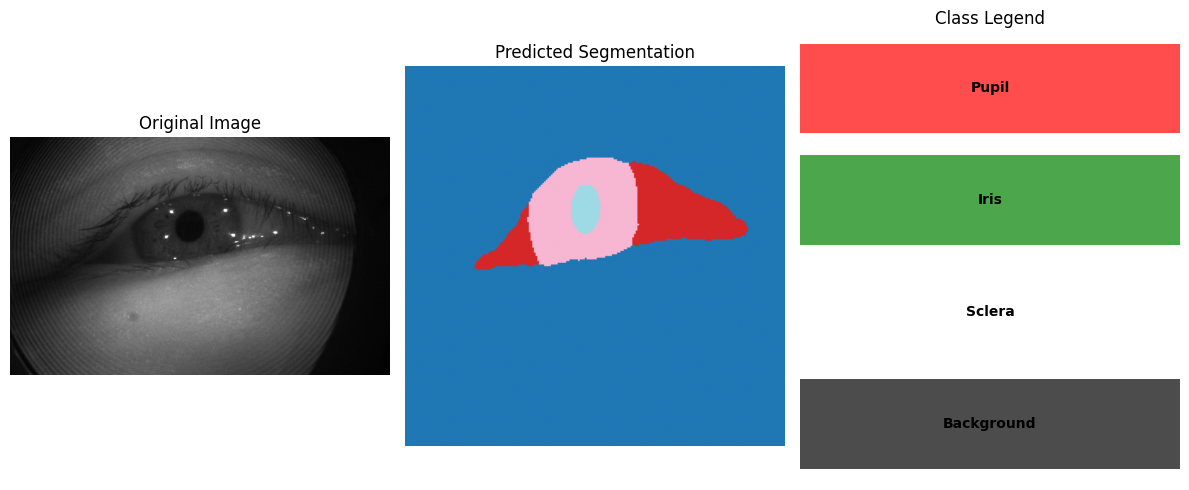

🎯 Starting Complete Model Visualization Pipeline
Extracting features from all layers...
✓ patch_extract_2: (1, 196, 256)
✓ patch_embedding_2: (1, 197, 768)


✓ adaptive_privacy_patch_drop_2: (1, 197, 768)


2025-10-05 09:43:00.354492: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 4 bytes spill stores, 4 bytes spill loads

2025-10-05 09:43:01.464116: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_5', 8 bytes spill stores, 8 bytes spill loads

2025-10-05 09:43:01.554430: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads

2025-10-05 09:43:01.604908: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10', 4 bytes spill stores, 4 bytes spill loads

2025-10-05 09:43:01.912064: I external/local_xla/xla/strea

✓ transformer_block_16: (1, 197, 768)
✓ transformer_block_17: (1, 197, 768)
✓ transformer_block_18: (1, 197, 768)
✓ transformer_block_19: (1, 197, 768)
✓ transformer_block_20: (1, 197, 768)
✓ transformer_block_21: (1, 197, 768)
✓ transformer_block_22: (1, 197, 768)
✓ transformer_block_23: (1, 197, 768)
✓ layer_normalization_50: (1, 197, 768)
✓ differential_privacy_layer_2: (1, 197, 768)
✓ get_item_2: (1, 196, 768)
✓ reshape_2: (1, 14, 14, 768)
✓ upsample_block_8: (1, 28, 28, 512)
✓ upsample_block_9: (1, 56, 56, 256)
✓ upsample_block_10: (1, 112, 112, 128)
✓ upsample_block_11: (1, 224, 224, 64)
✓ segmentation: (1, 224, 224, 4)

📸 Visualizing Patch Extraction...


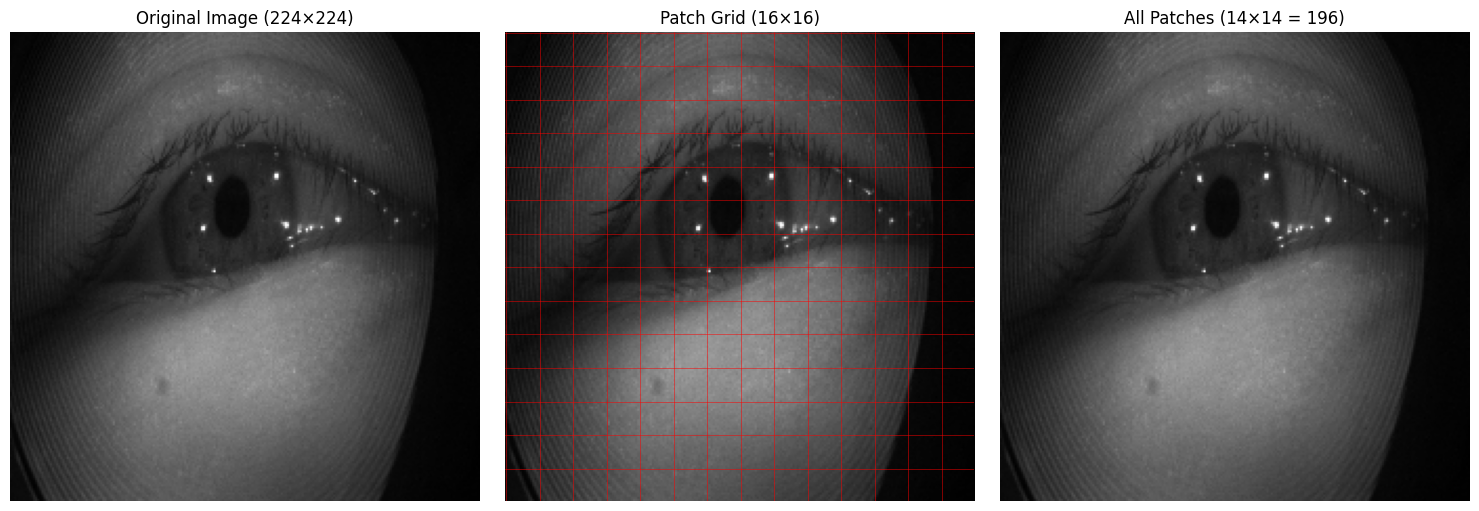


🔍 Visualizing Attention Patterns...


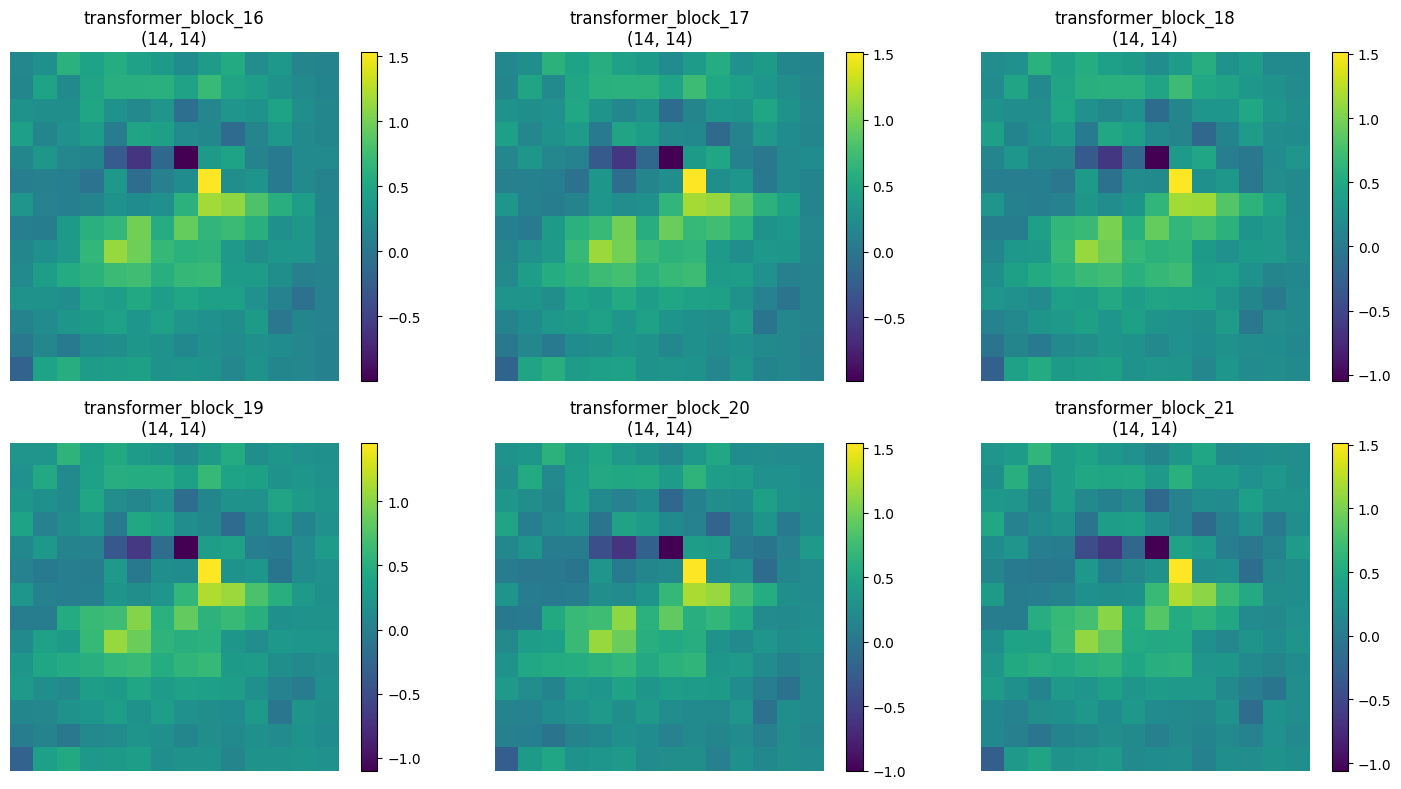


🔒 Visualizing Privacy Layers...


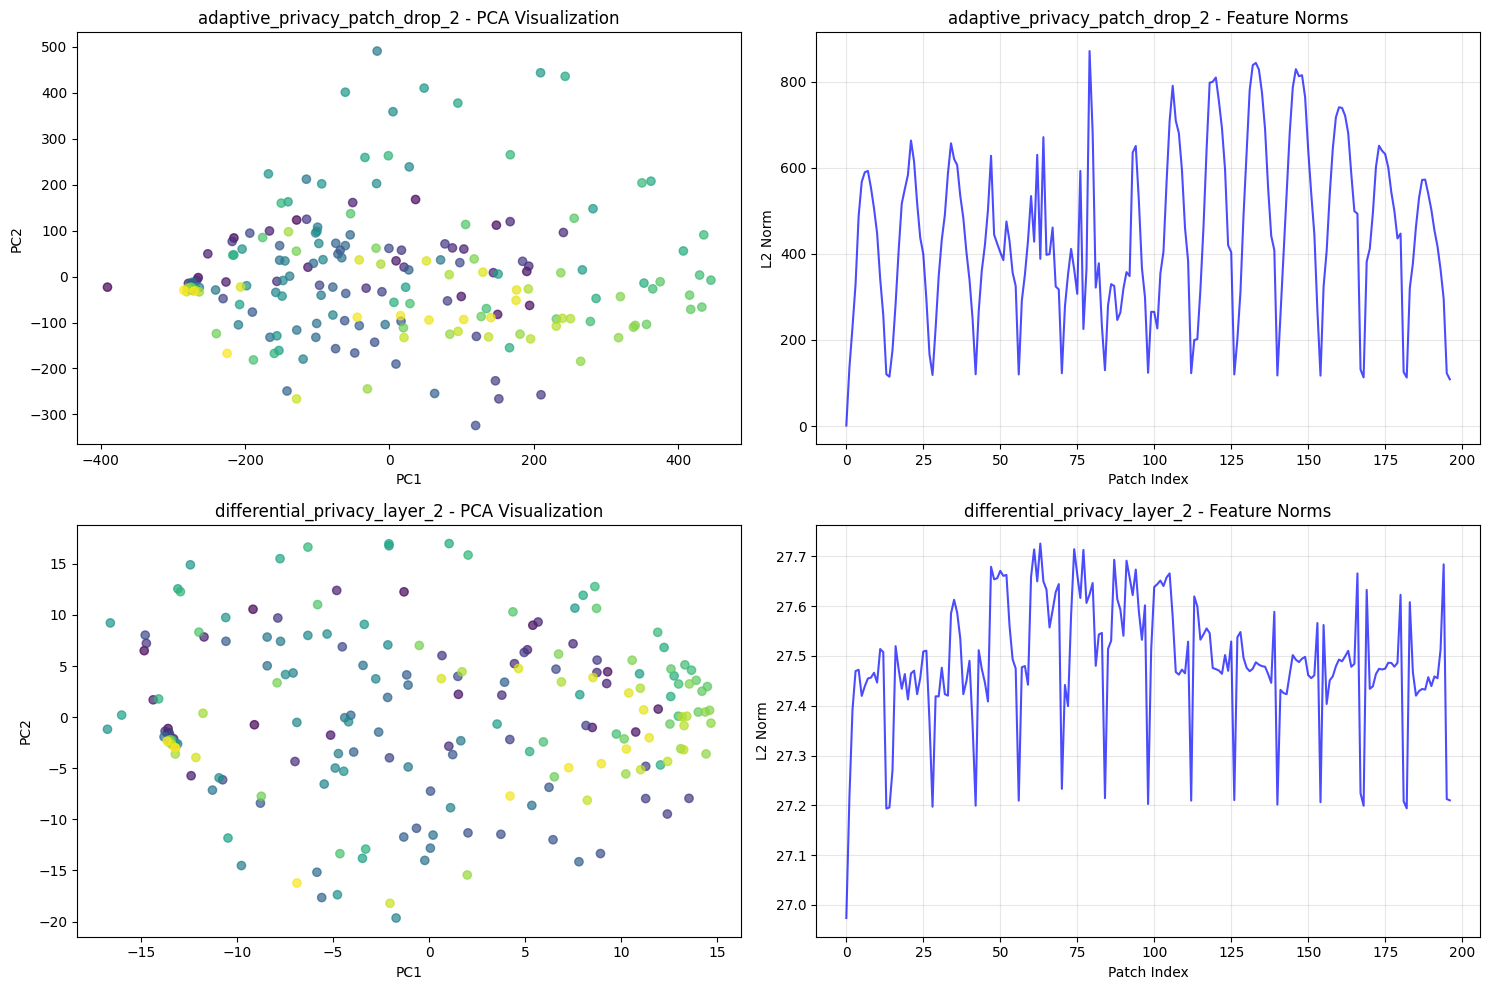


🔄 Visualizing Decoder Progression...


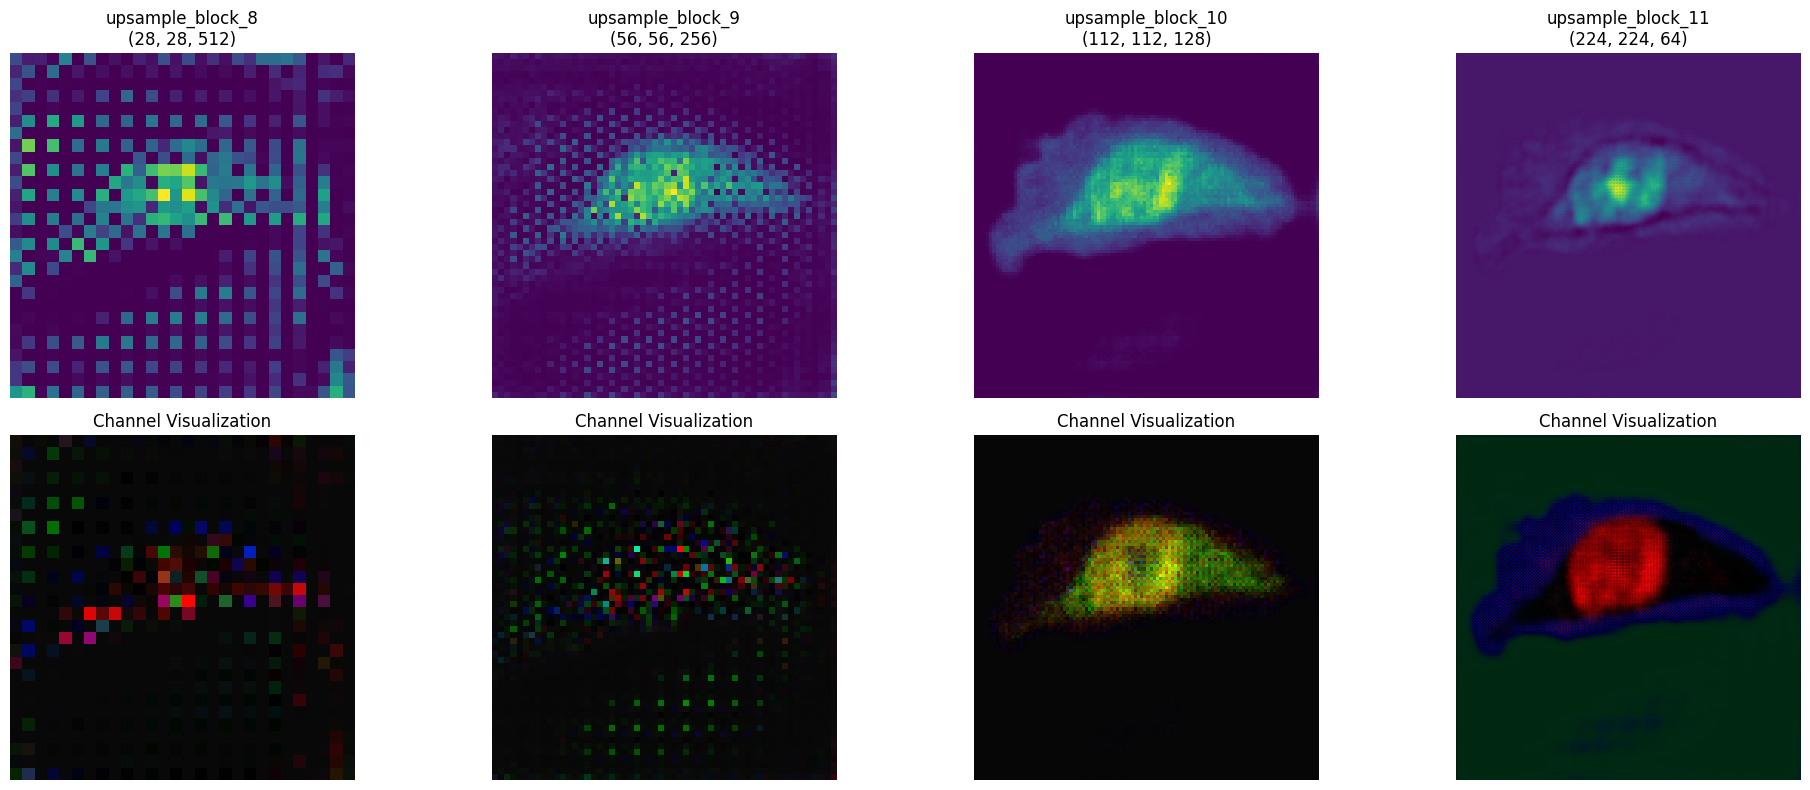


📊 Visualizing Feature Statistics...


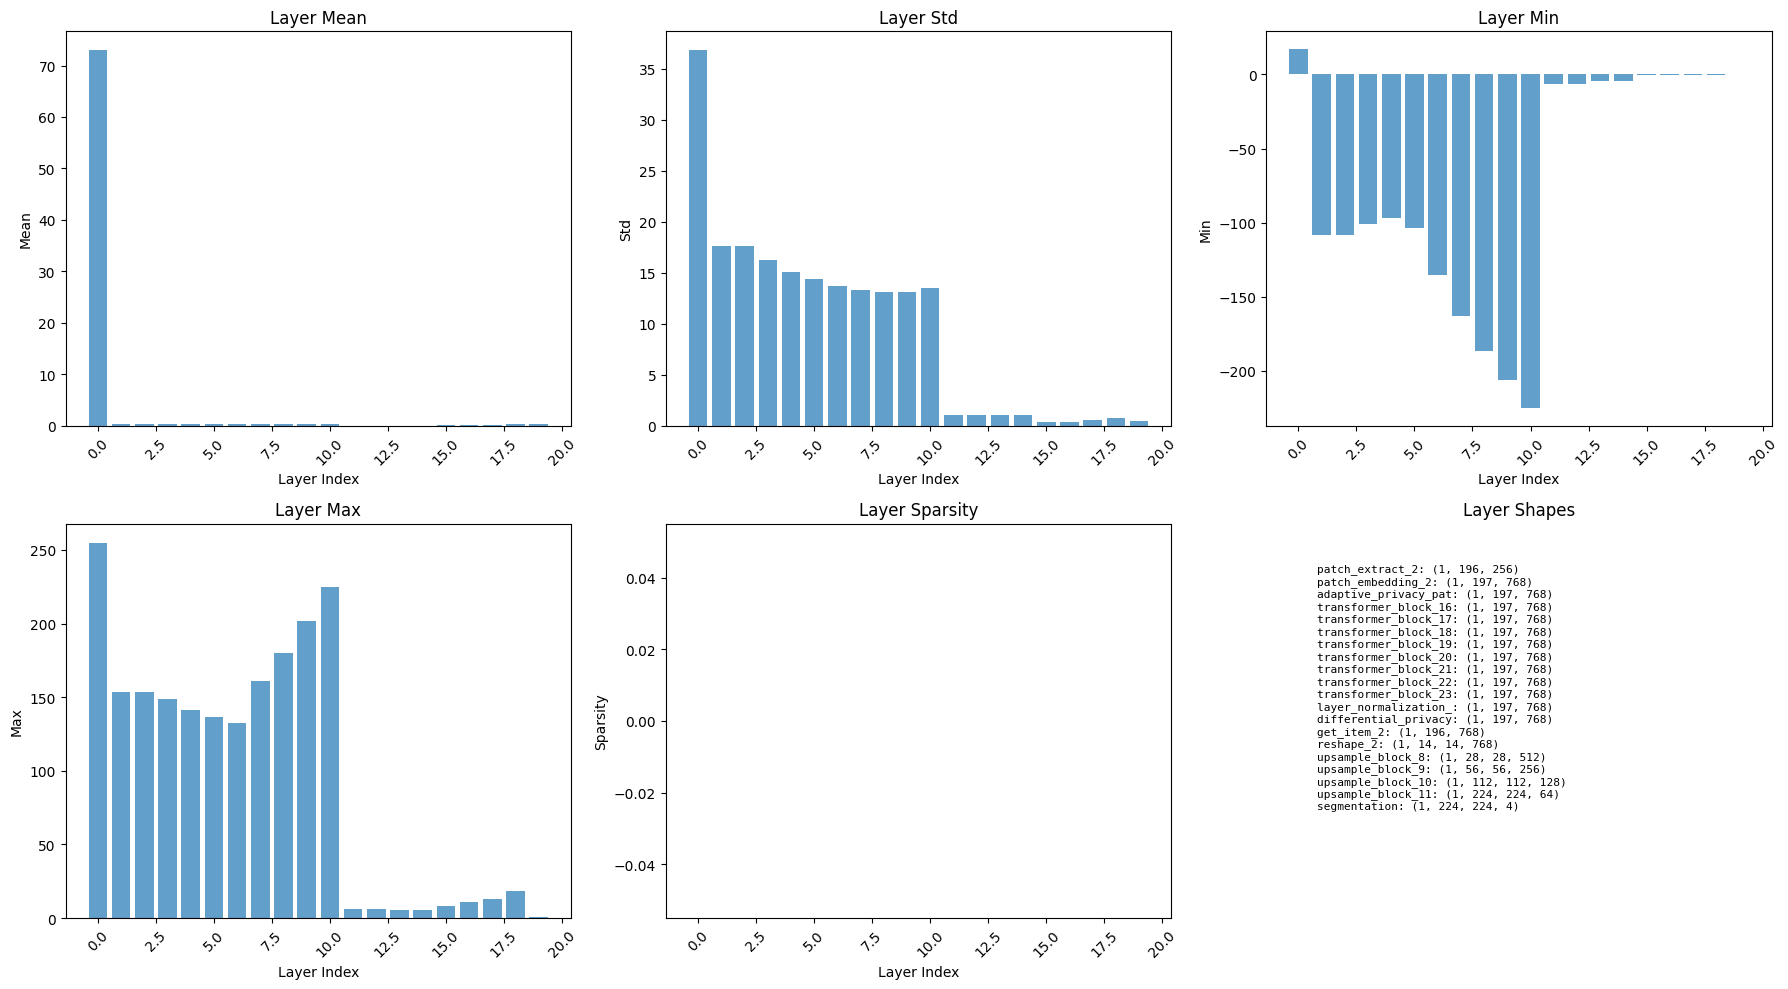


✅ Complete visualization finished!
Prediction completed! Mask shape: (224, 224)
Unique classes in prediction: [0 1 2 3]


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

class LayerVisualizationTool:
    """
    Comprehensive tool to visualize outputs from each layer of the ViT eye segmentation model
    """
    
    def __init__(self, model):
        self.model = model
        self.layer_outputs = {}
        self.feature_extractors = self._build_feature_extractors()
        
    def _build_feature_extractors(self):
        """Build feature extractors for each interesting layer"""
        extractors = {}
        
        # Get all layers
        for i, layer in enumerate(self.model.layers):
            layer_name = layer.name
            
            # Skip input layer and some intermediate layers that might cause issues
            if 'input' in layer_name.lower():
                continue
                
            try:
                # Create feature extractor for this layer
                extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=layer.output,
                    name=f"extractor_{layer_name}"
                )
                extractors[layer_name] = {
                    'extractor': extractor,
                    'layer_type': type(layer).__name__,
                    'layer_index': i
                }
            except Exception as e:
                print(f"Skipping layer {layer_name}: {str(e)}")
                
        return extractors
    
    def extract_all_features(self, image):
        """Extract features from all layers"""
        print("Extracting features from all layers...")
        
        for layer_name, layer_info in self.feature_extractors.items():
            try:
                features = layer_info['extractor'].predict(image, verbose=0)
                self.layer_outputs[layer_name] = {
                    'features': features,
                    'layer_type': layer_info['layer_type'],
                    'layer_index': layer_info['layer_index'],
                    'shape': features.shape
                }
                print(f"✓ {layer_name}: {features.shape}")
            except Exception as e:
                print(f"✗ Failed to extract from {layer_name}: {str(e)}")
    
    def visualize_patch_extraction(self, image, patch_size=16):
        """Visualize how the image is divided into patches"""
        plt.figure(figsize=(15, 5))
        
        # Original image
        plt.subplot(1, 3, 1)
        img_display = image[0].squeeze()
        plt.imshow(img_display, cmap='gray')
        plt.title('Original Image (224×224)')
        plt.axis('off')
        
        # Image with patch grid overlay
        plt.subplot(1, 3, 2)
        plt.imshow(img_display, cmap='gray')
        
        # Draw patch grid
        h, w = img_display.shape
        for i in range(0, h, patch_size):
            plt.axhline(y=i, color='red', linewidth=0.5, alpha=0.7)
        for j in range(0, w, patch_size):
            plt.axvline(x=j, color='red', linewidth=0.5, alpha=0.7)
        
        plt.title(f'Patch Grid ({patch_size}×{patch_size})')
        plt.axis('off')
        
        # Show some individual patches
        plt.subplot(1, 3, 3)
        patches_per_row = h // patch_size
        patches_per_col = w // patch_size
        
        # Create a visualization of all patches
        patch_mosaic = np.zeros((patches_per_row * patch_size, patches_per_col * patch_size))
        
        for i in range(patches_per_row):
            for j in range(patches_per_col):
                patch = img_display[i*patch_size:(i+1)*patch_size, 
                                  j*patch_size:(j+1)*patch_size]
                patch_mosaic[i*patch_size:(i+1)*patch_size,
                           j*patch_size:(j+1)*patch_size] = patch
        
        plt.imshow(patch_mosaic, cmap='gray')
        plt.title(f'All Patches ({patches_per_row}×{patches_per_col} = {patches_per_row*patches_per_col})')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_attention_patterns(self):
        """Visualize attention patterns from transformer layers"""
        attention_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if 'attention' in layer_name.lower() or 'transformer' in layer_name.lower():
                attention_layers.append((layer_name, output_info))
        
        if not attention_layers:
            print("No attention layers found for visualization")
            return
        
        # Visualize attention patterns
        fig, axes = plt.subplots(2, min(3, len(attention_layers)), figsize=(15, 8))
        if len(attention_layers) == 1:
            axes = axes.reshape(2, 1)
        
        for idx, (layer_name, output_info) in enumerate(attention_layers[:6]):
            if idx >= 6:
                break
                
            features = output_info['features'][0]  # Remove batch dimension
            
            # Reshape if needed (remove class token if present)
            if len(features.shape) == 2:  # (seq_len, embed_dim)
                if features.shape[0] == 197:  # 196 patches + 1 class token
                    features = features[1:]  # Remove class token
                
                # Reshape to spatial dimensions
                spatial_size = int(np.sqrt(features.shape[0]))
                if spatial_size * spatial_size == features.shape[0]:
                    # Average across embedding dimension for visualization
                    spatial_features = features.mean(axis=-1)
                    spatial_features = spatial_features.reshape(spatial_size, spatial_size)
                    
                    row = idx // 3
                    col = idx % 3
                    
                    if len(attention_layers) <= 3:
                        ax = axes[row] if axes.ndim == 1 else axes[row, col]
                    else:
                        ax = axes[row, col] if axes.ndim == 2 else axes[idx]
                    
                    im = ax.imshow(spatial_features, cmap='viridis')
                    ax.set_title(f'{layer_name}\n{spatial_features.shape}')
                    ax.axis('off')
                    plt.colorbar(im, ax=ax, fraction=0.046)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_privacy_layers(self):
        """Visualize privacy-preserving layer outputs"""
        privacy_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if 'privacy' in layer_name.lower() or 'adaptive' in layer_name.lower():
                privacy_layers.append((layer_name, output_info))
        
        if not privacy_layers:
            print("No privacy layers found")
            return
        
        plt.figure(figsize=(15, 10))
        
        for idx, (layer_name, output_info) in enumerate(privacy_layers):
            features = output_info['features'][0]  # Remove batch dimension
            
            if len(features.shape) == 2:  # (seq_len, embed_dim)
                # Show first few dimensions of embeddings
                plt.subplot(len(privacy_layers), 2, idx*2 + 1)
                
                # PCA for visualization if embedding dim > 3
                if features.shape[-1] > 3:
                    pca = PCA(n_components=min(3, features.shape[-1]))
                    features_pca = pca.fit_transform(features)
                    plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                              c=range(len(features_pca)), cmap='viridis', alpha=0.7)
                    plt.title(f'{layer_name} - PCA Visualization')
                    plt.xlabel('PC1')
                    plt.ylabel('PC2')
                else:
                    plt.imshow(features.T, aspect='auto', cmap='viridis')
                    plt.title(f'{layer_name} - Feature Map')
                    plt.xlabel('Sequence Position')
                    plt.ylabel('Embedding Dimension')
                
                # Show embedding statistics
                plt.subplot(len(privacy_layers), 2, idx*2 + 2)
                feature_norms = np.linalg.norm(features, axis=-1)
                plt.plot(feature_norms, 'b-', alpha=0.7)
                plt.title(f'{layer_name} - Feature Norms')
                plt.xlabel('Patch Index')
                plt.ylabel('L2 Norm')
                plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_decoder_progression(self):
        """Visualize how the decoder upsamples features"""
        decoder_layers = []
        
        for layer_name, output_info in self.layer_outputs.items():
            if ('upsample' in layer_name.lower() or 
                'conv2d_transpose' in layer_name.lower() or
                'decoder' in layer_name.lower()):
                decoder_layers.append((layer_name, output_info))
        
        if not decoder_layers:
            print("No decoder layers found")
            return
        
        # Sort by layer index to show progression
        decoder_layers.sort(key=lambda x: x[1]['layer_index'])
        
        plt.figure(figsize=(20, 8))
        
        for idx, (layer_name, output_info) in enumerate(decoder_layers):
            features = output_info['features'][0]  # Remove batch dimension
            
            if len(features.shape) == 3:  # (H, W, C)
                # Average across channels for visualization
                feature_map = features.mean(axis=-1)
                
                plt.subplot(2, len(decoder_layers), idx + 1)
                plt.imshow(feature_map, cmap='viridis')
                plt.title(f'{layer_name}\n{features.shape}')
                plt.axis('off')
                
                # Show some individual channels
                plt.subplot(2, len(decoder_layers), len(decoder_layers) + idx + 1)
                if features.shape[-1] >= 3:
                    # Show RGB-like visualization of first 3 channels
                    rgb_vis = features[:, :, :3]
                    rgb_vis = (rgb_vis - rgb_vis.min()) / (rgb_vis.max() - rgb_vis.min())
                    plt.imshow(rgb_vis)
                else:
                    plt.imshow(features[:, :, 0], cmap='viridis')
                plt.title(f'Channel Visualization')
                plt.axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_feature_statistics(self):
        """Show statistics of features across layers"""
        layer_names = []
        layer_shapes = []
        param_counts = []
        activation_stats = []
        
        for layer_name, output_info in self.layer_outputs.items():
            features = output_info['features']
            
            layer_names.append(layer_name[:20])  # Truncate long names
            layer_shapes.append(str(features.shape))
            
            # Calculate statistics
            stats = {
                'mean': np.mean(features),
                'std': np.std(features),
                'min': np.min(features),
                'max': np.max(features),
                'sparsity': np.mean(features == 0) * 100
            }
            activation_stats.append(stats)
        
        # Create statistics visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        stats_keys = ['mean', 'std', 'min', 'max', 'sparsity']
        
        for idx, stat_key in enumerate(stats_keys):
            row = idx // 3
            col = idx % 3
            
            values = [stats[stat_key] for stats in activation_stats]
            
            axes[row, col].bar(range(len(values)), values, alpha=0.7)
            axes[row, col].set_title(f'Layer {stat_key.capitalize()}')
            axes[row, col].set_xlabel('Layer Index')
            axes[row, col].set_ylabel(stat_key.capitalize())
            axes[row, col].tick_params(axis='x', rotation=45)
            
            # Add layer names on x-axis
            if len(layer_names) <= 10:
                axes[row, col].set_xticks(range(len(layer_names)))
                axes[row, col].set_xticklabels(layer_names, rotation=45, ha='right')
        
        # Layer shapes info
        axes[1, 2].axis('off')
        shape_text = "\n".join([f"{name}: {shape}" for name, shape in zip(layer_names, layer_shapes)])
        axes[1, 2].text(0.1, 0.9, shape_text, transform=axes[1, 2].transAxes, 
                        fontsize=8, verticalalignment='top', fontfamily='monospace')
        axes[1, 2].set_title('Layer Shapes')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_complete_pipeline(self, image, save_plots=False):
        """Complete visualization of the entire model pipeline"""
        print("🎯 Starting Complete Model Visualization Pipeline")
        print("=" * 60)
        
        # 1. Extract features from all layers
        self.extract_all_features(image)
        
        # 2. Visualize patch extraction
        print("\n📸 Visualizing Patch Extraction...")
        self.visualize_patch_extraction(image)
        
        # 3. Visualize attention patterns
        print("\n🔍 Visualizing Attention Patterns...")
        self.visualize_attention_patterns()
        
        # 4. Visualize privacy layers
        print("\n🔒 Visualizing Privacy Layers...")
        self.visualize_privacy_layers()
        
        # 5. Visualize decoder progression
        print("\n🔄 Visualizing Decoder Progression...")
        self.visualize_decoder_progression()
        
        # 6. Show feature statistics
        print("\n📊 Visualizing Feature Statistics...")
        self.visualize_feature_statistics()
        
        print("\n✅ Complete visualization finished!")

def load_and_predict_with_visualization(model, image_path):
    """Load image, predict, and visualize everything"""
    
    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    # img = img.astype(np.float32) / 255.0  # Normalize
    
    # Predict
    predicted_mask = model.predict(img)
    predicted_mask = np.argmax(predicted_mask, axis=-1)[0]
    
    # Show final prediction
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask, cmap='tab20')
    plt.title('Predicted Segmentation')
    plt.axis('off')
    
    # Color legend
    plt.subplot(1, 3, 3)
    colors = ['black', 'white', 'green', 'red']
    labels = ['Background', 'Sclera', 'Iris', 'Pupil']
    for i, (color, label) in enumerate(zip(colors, labels)):
        plt.barh(i, 1, color=color, alpha=0.7)
        plt.text(0.5, i, label, ha='center', va='center', fontweight='bold')
    plt.xlim(0, 1)
    plt.ylim(-0.5, len(labels)-0.5)
    plt.axis('off')
    plt.title('Class Legend')
    
    plt.tight_layout()
    plt.show()
    
    # Create visualization tool and run complete pipeline
    viz_tool = LayerVisualizationTool(model)
    viz_tool.visualize_complete_pipeline(img)
    
    return predicted_mask, viz_tool

# Usage example
if __name__ == "__main__":
    # Your existing code
    image_path = './openEDS/openEDS/S_15/100.png'
    
    # Assuming you have your model loaded
    # model = your_trained_model
    
    # Run complete visualization
    predicted_mask, viz_tool = load_and_predict_with_visualization(model, image_path)
    
    print(f"Prediction completed! Mask shape: {predicted_mask.shape}")
    print(f"Unique classes in prediction: {np.unique(predicted_mask)}")

Found Adaptive Patch Drop layer: adaptive_privacy_patch_drop
🎯 Visualizing Adaptive Privacy Patch Dropout Layer

📸 Analyzing single image patch sensitivity and dropout...


2025-11-19 13:23:52.770198: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.17GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-19 13:23:53.150880: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.10GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-19 13:23:53.332242: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.08GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-19 13:23:53.517051: W external/local_xla/xla/ts

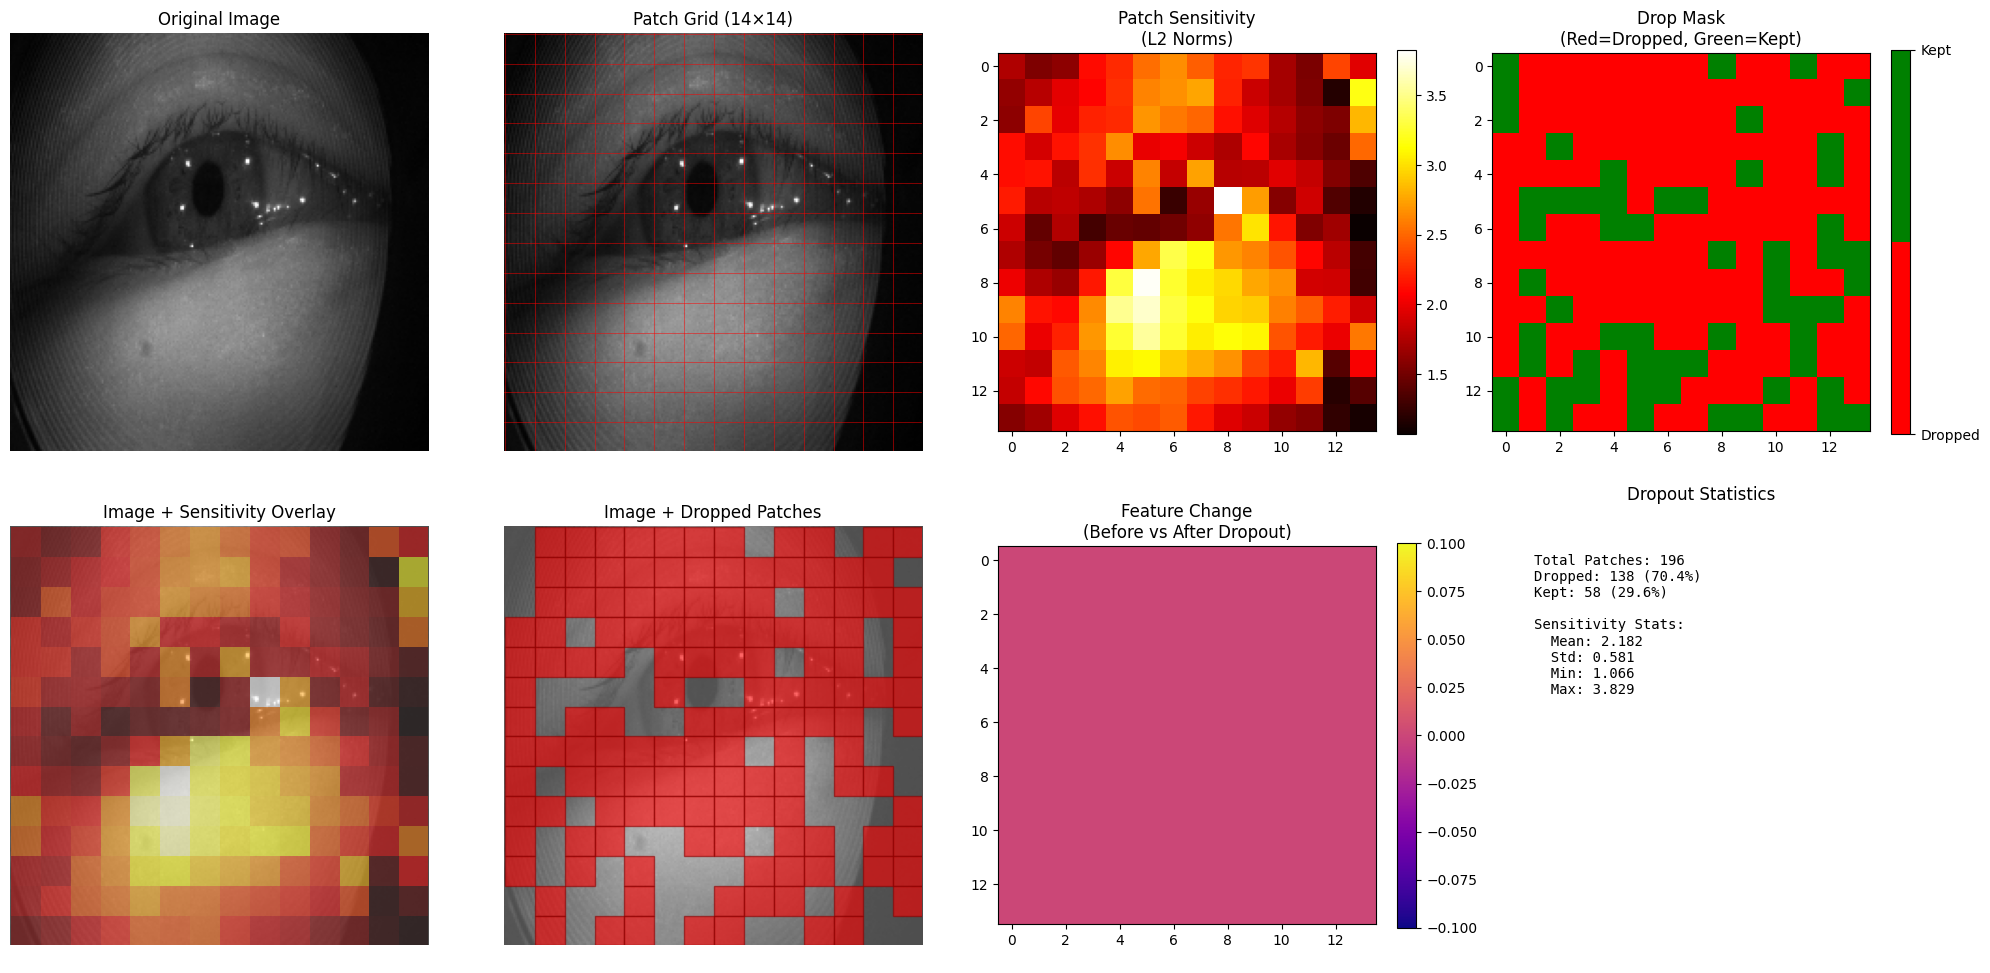


📊 Analyzing batch of 5 images for privacy effectiveness...
🔒 Analyzing Privacy Effectiveness of Adaptive Patch Dropout


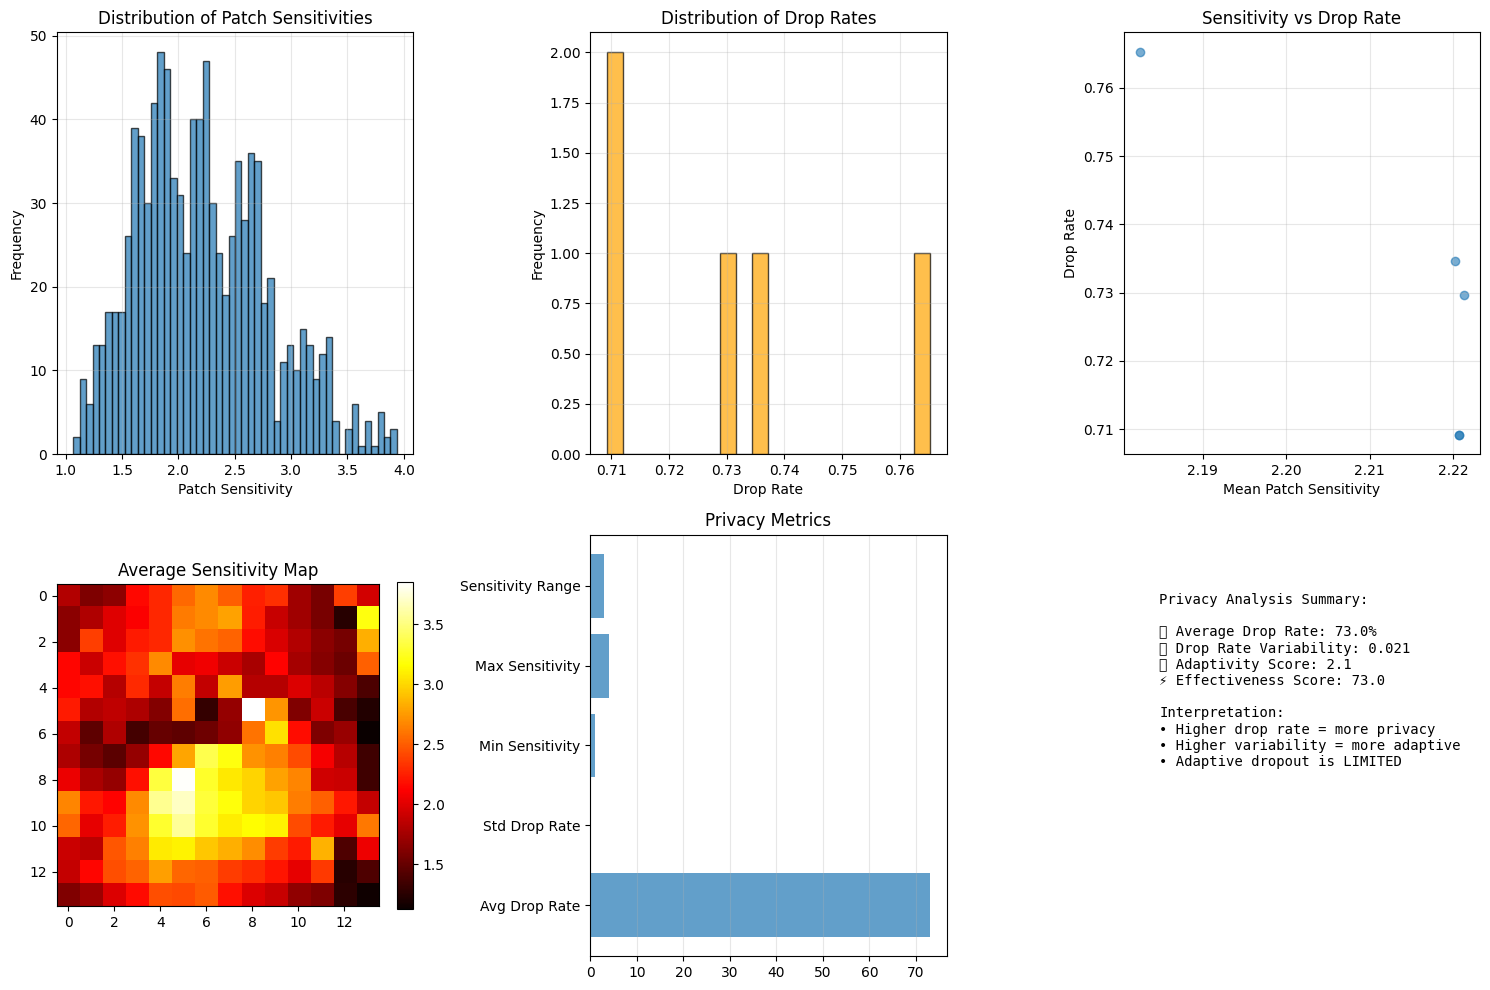


✅ Privacy Analysis Complete!
   Average Drop Rate: 73.0%
   Adaptivity Score: 2.07
   Effectiveness Score: 72.96


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

class AdaptivePatchDropVisualizer:
    """
    Specialized visualizer for Adaptive Privacy Patch Drop layer
    Shows which patches are dropped, sensitivity maps, and privacy analysis
    """
    
    def __init__(self, model):
        self.model = model
        self.patch_drop_layer = None
        self.patch_drop_extractor = None
        self.patch_extractor = None
        self.patch_embedding_extractor = None
        self._find_patch_drop_layer()
        
    def _find_patch_drop_layer(self):
        """Find the AdaptivePrivacyPatchDrop layer in the model"""
        for layer in self.model.layers:
            if 'adaptive' in layer.name.lower() and 'drop' in layer.name.lower():
                self.patch_drop_layer = layer
                print(f"Found Adaptive Patch Drop layer: {layer.name}")
                break
        
        if self.patch_drop_layer is None:
            print("❌ AdaptivePrivacyPatchDrop layer not found!")
            return
        
        # Build extractors for different stages
        self._build_extractors()
    
    def _build_extractors(self):
        """Build feature extractors for patch analysis"""
        try:
            # Find patch extraction layer
            patch_extract_layer = None
            patch_embedding_layer = None
            
            for layer in self.model.layers:
                if 'patch' in layer.name.lower() and 'extract' in layer.name.lower():
                    patch_extract_layer = layer
                elif 'patch' in layer.name.lower() and 'embedding' in layer.name.lower():
                    patch_embedding_layer = layer
            
            # Create extractors
            if patch_extract_layer:
                self.patch_extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=patch_extract_layer.output
                )
            
            if patch_embedding_layer:
                self.patch_embedding_extractor = tf.keras.Model(
                    inputs=self.model.input,
                    outputs=patch_embedding_layer.output
                )
            
            # Extractor for patch drop layer output
            self.patch_drop_extractor = tf.keras.Model(
                inputs=self.model.input,
                outputs=self.patch_drop_layer.output
            )
            
        except Exception as e:
            print(f"Error building extractors: {e}")
    
    def extract_patch_features(self, image):
        """Extract features at different stages of patch processing"""
        features = {}
        
        try:
            # Original patches
            if self.patch_extractor:
                features['raw_patches'] = self.patch_extractor.predict(image, verbose=0)
            
            # Embedded patches (before dropout)
            if self.patch_embedding_extractor:
                features['embedded_patches'] = self.patch_embedding_extractor.predict(image, verbose=0)
            
            # After patch dropout
            if self.patch_drop_extractor:
                features['dropped_patches'] = self.patch_drop_extractor.predict(image, verbose=0)
            
        except Exception as e:
            print(f"Error extracting features: {e}")
        
        return features
    
    def get_drop_mask_and_sensitivity(self, image):
        """
        Extract the actual drop mask and sensitivity scores from the layer
        This requires modifying the layer to expose intermediate values
        """
        # Create a modified version of the model that outputs intermediate values
        try:
            # We need to access the layer's internal state
            # This is a bit hacky but necessary to visualize the drop patterns
            
            # Get the layer's weights (sensitivity weights)
            if hasattr(self.patch_drop_layer, 'sensitivity_weights'):
                sensitivity_weights = self.patch_drop_layer.sensitivity_weights.numpy()
            else:
                sensitivity_weights = None
            
            # To get the actual mask, we need to run the model in training mode
            # and access the layer's last_mask attribute
            
            # Set training mode
            with tf.GradientTape() as tape:
                _ = self.model(image, training=True)
            
            # Get the last mask if available
            drop_mask = None
            if hasattr(self.patch_drop_layer, 'last_mask') and self.patch_drop_layer.last_mask is not None:
                drop_mask = self.patch_drop_layer.last_mask.numpy()
            
            return drop_mask, sensitivity_weights
            
        except Exception as e:
            print(f"Error getting drop mask: {e}")
            return None, None
    
    def visualize_patch_sensitivity(self, image, patch_size=16):
        """Visualize patch sensitivity and drop patterns"""
        
        # Extract features
        features = self.extract_patch_features(image)
        drop_mask, sensitivity_weights = self.get_drop_mask_and_sensitivity(image)
        
        if not features:
            print("No features extracted!")
            return
        
        # Calculate spatial dimensions
        img_size = 224
        patches_per_side = img_size // patch_size
        
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        # 1. Original Image
        img_display = image[0].squeeze()
        axes[0, 0].imshow(img_display, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')
        
        # 2. Patch Grid
        axes[0, 1].imshow(img_display, cmap='gray')
        self._draw_patch_grid(axes[0, 1], img_size, patch_size)
        axes[0, 1].set_title(f'Patch Grid ({patches_per_side}×{patches_per_side})')
        axes[0, 1].axis('off')
        
        # 3. Patch Sensitivity Heatmap
        if 'embedded_patches' in features:
            embedded = features['embedded_patches'][0]  # Remove batch dim
            if embedded.shape[0] == 197:  # Remove class token if present
                embedded = embedded[1:]
            
            # Calculate patch norms as sensitivity proxy
            patch_norms = np.linalg.norm(embedded, axis=-1)
            sensitivity_map = patch_norms.reshape(patches_per_side, patches_per_side)
            
            im1 = axes[0, 2].imshow(sensitivity_map, cmap='hot', interpolation='nearest')
            axes[0, 2].set_title('Patch Sensitivity\n(L2 Norms)')
            plt.colorbar(im1, ax=axes[0, 2], fraction=0.046)
            
        # 4. Drop Mask Visualization
        if drop_mask is not None:
            # drop_mask shape: (batch, num_patches, 1)
            mask_2d = drop_mask[0, :, 0]  # Remove batch and channel dims
            if len(mask_2d) == 197:  # Remove class token if present
                mask_2d = mask_2d[1:]
            
            mask_spatial = mask_2d.reshape(patches_per_side, patches_per_side)
            
            # Create custom colormap: dropped=red, kept=green
            colors = ['red', 'green']
            cmap = ListedColormap(colors)
            
            im2 = axes[0, 3].imshow(mask_spatial, cmap=cmap, vmin=0, vmax=1)
            axes[0, 3].set_title('Drop Mask\n(Red=Dropped, Green=Kept)')
            cbar = plt.colorbar(im2, ax=axes[0, 3], fraction=0.046, ticks=[0, 1])
            cbar.ax.set_yticklabels(['Dropped', 'Kept'])
        else:
            axes[0, 3].text(0.5, 0.5, 'Drop mask\nnot available', 
                           ha='center', va='center', transform=axes[0, 3].transAxes)
            axes[0, 3].set_title('Drop Mask')
        
        # 5. Overlay: Original + Sensitivity
        axes[1, 0].imshow(img_display, cmap='gray', alpha=0.7)
        if 'embedded_patches' in features:
            # Overlay sensitivity as colored patches
            self._overlay_patch_values(axes[1, 0], sensitivity_map, patch_size, alpha=0.5, cmap='hot')
        axes[1, 0].set_title('Image + Sensitivity Overlay')
        axes[1, 0].axis('off')
        
        # 6. Overlay: Original + Drop Mask
        axes[1, 1].imshow(img_display, cmap='gray', alpha=0.7)
        if drop_mask is not None:
            # Overlay dropped patches in red
            self._overlay_dropped_patches(axes[1, 1], mask_spatial, patch_size)
        axes[1, 1].set_title('Image + Dropped Patches')
        axes[1, 1].axis('off')
        
        # 7. Feature Comparison: Before vs After Dropout
        if 'embedded_patches' in features and 'dropped_patches' in features:
            before = features['embedded_patches'][0]
            after = features['dropped_patches'][0]
            
            if before.shape[0] == 197:  # Remove class token
                before = before[1:]
            if after.shape[0] == 197:
                after = after[1:]
            
            # Calculate difference
            diff = np.linalg.norm(before - after, axis=-1)
            diff_map = diff.reshape(patches_per_side, patches_per_side)
            
            im3 = axes[1, 2].imshow(diff_map, cmap='plasma', interpolation='nearest')
            axes[1, 2].set_title('Feature Change\n(Before vs After Dropout)')
            plt.colorbar(im3, ax=axes[1, 2], fraction=0.046)
        
        # 8. Statistics
        axes[1, 3].axis('off')
        stats_text = self._calculate_dropout_statistics(features, drop_mask)
        axes[1, 3].text(0.1, 0.9, stats_text, transform=axes[1, 3].transAxes,
                       fontsize=10, verticalalignment='top', fontfamily='monospace')
        axes[1, 3].set_title('Dropout Statistics')
        
        plt.tight_layout()
        plt.show()
    
    def _draw_patch_grid(self, ax, img_size, patch_size):
        """Draw patch grid overlay"""
        for i in range(0, img_size, patch_size):
            ax.axhline(y=i, color='red', linewidth=0.5, alpha=0.7)
            ax.axvline(x=i, color='red', linewidth=0.5, alpha=0.7)
    
    def _overlay_patch_values(self, ax, values, patch_size, alpha=0.5, cmap='hot'):
        """Overlay patch values on image"""
        patches_per_side = values.shape[0]
        for i in range(patches_per_side):
            for j in range(patches_per_side):
                value = values[i, j]
                normalized_value = (value - values.min()) / (values.max() - values.min())
                
                rect = Rectangle((j * patch_size, i * patch_size), 
                               patch_size, patch_size,
                               facecolor=plt.cm.get_cmap(cmap)(normalized_value),
                               alpha=alpha)
                ax.add_patch(rect)
    
    def _overlay_dropped_patches(self, ax, mask, patch_size):
        """Overlay dropped patches in red"""
        patches_per_side = mask.shape[0]
        for i in range(patches_per_side):
            for j in range(patches_per_side):
                if mask[i, j] == 0:  # Dropped patch
                    rect = Rectangle((j * patch_size, i * patch_size), 
                                   patch_size, patch_size,
                                   facecolor='red', alpha=0.6, edgecolor='darkred')
                    ax.add_patch(rect)
    
    def _calculate_dropout_statistics(self, features, drop_mask):
        """Calculate and format dropout statistics"""
        stats = []
        
        if drop_mask is not None:
            mask = drop_mask[0, :, 0]  # Remove batch and channel dims
            if len(mask) == 197:  # Remove class token
                mask = mask[1:]
            
            total_patches = len(mask)
            dropped_patches = np.sum(mask == 0)
            kept_patches = np.sum(mask == 1)
            drop_rate = dropped_patches / total_patches * 100
            
            stats.append(f"Total Patches: {total_patches}")
            stats.append(f"Dropped: {dropped_patches} ({drop_rate:.1f}%)")
            stats.append(f"Kept: {kept_patches} ({100-drop_rate:.1f}%)")
            stats.append("")
        
        if 'embedded_patches' in features:
            embedded = features['embedded_patches'][0]
            if embedded.shape[0] == 197:
                embedded = embedded[1:]
            
            patch_norms = np.linalg.norm(embedded, axis=-1)
            stats.append(f"Sensitivity Stats:")
            stats.append(f"  Mean: {patch_norms.mean():.3f}")
            stats.append(f"  Std: {patch_norms.std():.3f}")
            stats.append(f"  Min: {patch_norms.min():.3f}")
            stats.append(f"  Max: {patch_norms.max():.3f}")
        
        return "\n".join(stats)
    
    def analyze_privacy_effectiveness(self, images_batch, labels=None):
        """
        Analyze how effective the patch dropout is for privacy
        """
        print("🔒 Analyzing Privacy Effectiveness of Adaptive Patch Dropout")
        print("=" * 60)
        
        all_sensitivities = []
        all_drop_rates = []
        
        for i, image in enumerate(images_batch):
            image_batch = np.expand_dims(image, axis=0)
            
            # Extract features
            features = self.extract_patch_features(image_batch)
            drop_mask, _ = self.get_drop_mask_and_sensitivity(image_batch)
            
            if 'embedded_patches' in features and drop_mask is not None:
                embedded = features['embedded_patches'][0]
                if embedded.shape[0] == 197:
                    embedded = embedded[1:]
                
                mask = drop_mask[0, :, 0]
                if len(mask) == 197:
                    mask = mask[1:]
                
                # Calculate sensitivity
                patch_sensitivity = np.linalg.norm(embedded, axis=-1)
                all_sensitivities.append(patch_sensitivity)
                
                # Calculate drop rate
                drop_rate = np.sum(mask == 0) / len(mask)
                all_drop_rates.append(drop_rate)
        
        if all_sensitivities:
            # Analyze patterns
            plt.figure(figsize=(15, 10))
            
            # 1. Sensitivity distribution
            plt.subplot(2, 3, 1)
            all_sens_flat = np.concatenate(all_sensitivities)
            plt.hist(all_sens_flat, bins=50, alpha=0.7, edgecolor='black')
            plt.xlabel('Patch Sensitivity')
            plt.ylabel('Frequency')
            plt.title('Distribution of Patch Sensitivities')
            plt.grid(True, alpha=0.3)
            
            # 2. Drop rate distribution
            plt.subplot(2, 3, 2)
            plt.hist(all_drop_rates, bins=20, alpha=0.7, edgecolor='black', color='orange')
            plt.xlabel('Drop Rate')
            plt.ylabel('Frequency')
            plt.title('Distribution of Drop Rates')
            plt.grid(True, alpha=0.3)
            
            # 3. Sensitivity vs Drop Rate correlation
            plt.subplot(2, 3, 3)
            mean_sensitivities = [np.mean(sens) for sens in all_sensitivities]
            plt.scatter(mean_sensitivities, all_drop_rates, alpha=0.6)
            plt.xlabel('Mean Patch Sensitivity')
            plt.ylabel('Drop Rate')
            plt.title('Sensitivity vs Drop Rate')
            plt.grid(True, alpha=0.3)
            
            # 4. Spatial pattern analysis
            plt.subplot(2, 3, 4)
            if len(all_sensitivities) > 0:
                # Average sensitivity across all images
                avg_sensitivity = np.mean(all_sensitivities, axis=0)
                patches_per_side = int(np.sqrt(len(avg_sensitivity)))
                sensitivity_map = avg_sensitivity.reshape(patches_per_side, patches_per_side)
                
                im = plt.imshow(sensitivity_map, cmap='hot', interpolation='nearest')
                plt.title('Average Sensitivity Map')
                plt.colorbar(im, fraction=0.046)
            
            # 5. Privacy metrics
            plt.subplot(2, 3, 5)
            privacy_metrics = {
                'Avg Drop Rate': f"{np.mean(all_drop_rates):.2%}",
                'Std Drop Rate': f"{np.std(all_drop_rates):.3f}",
                'Min Sensitivity': f"{np.min(all_sens_flat):.3f}",
                'Max Sensitivity': f"{np.max(all_sens_flat):.3f}",
                'Sensitivity Range': f"{np.max(all_sens_flat) - np.min(all_sens_flat):.3f}"
            }
            
            y_pos = np.arange(len(privacy_metrics))
            plt.barh(y_pos, [float(v.strip('%')) if '%' in v else float(v) 
                           for v in privacy_metrics.values()], alpha=0.7)
            plt.yticks(y_pos, privacy_metrics.keys())
            plt.title('Privacy Metrics')
            plt.grid(True, alpha=0.3, axis='x')
            
            # 6. Effectiveness summary
            plt.subplot(2, 3, 6)
            plt.axis('off')
            
            effectiveness_score = np.mean(all_drop_rates) * 100
            adaptivity_score = np.std(all_drop_rates) * 100
            
            summary_text = f"""
Privacy Analysis Summary:

🎯 Average Drop Rate: {np.mean(all_drop_rates):.1%}
📊 Drop Rate Variability: {np.std(all_drop_rates):.3f}
🔄 Adaptivity Score: {adaptivity_score:.1f}
⚡ Effectiveness Score: {effectiveness_score:.1f}

Interpretation:
• Higher drop rate = more privacy
• Higher variability = more adaptive
• Adaptive dropout is {'WORKING' if adaptivity_score > 5 else 'LIMITED'}
            """
            
            plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
                    fontsize=10, verticalalignment='top', fontfamily='monospace')
            
            plt.tight_layout()
            plt.show()
            
            return {
                'mean_drop_rate': np.mean(all_drop_rates),
                'std_drop_rate': np.std(all_drop_rates),
                'mean_sensitivity': np.mean(all_sens_flat),
                'adaptivity_score': adaptivity_score,
                'effectiveness_score': effectiveness_score
            }
        
        return None

# Enhanced usage function
def visualize_adaptive_patch_dropout_complete(model, image_path, num_samples=5):
    """
    Complete visualization of Adaptive Patch Dropout layer
    """
    
    # Load and preprocess image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(image, (224, 224))
    img = np.expand_dims(img, axis=-1)
    img = np.expand_dims(img, axis=0)
    img = img.astype(np.float32) / 255.0
    
    # Create visualizer
    visualizer = AdaptivePatchDropVisualizer(model)
    
    if visualizer.patch_drop_layer is None:
        print("❌ No Adaptive Patch Drop layer found in the model!")
        return
    
    print("🎯 Visualizing Adaptive Privacy Patch Dropout Layer")
    print("=" * 60)
    
    # 1. Visualize single image
    print("\n📸 Analyzing single image patch sensitivity and dropout...")
    visualizer.visualize_patch_sensitivity(img)
    
    # 2. Batch analysis (if you have multiple images)
    # For demo, we'll create variations of the same image
    print(f"\n📊 Analyzing batch of {num_samples} images for privacy effectiveness...")
    
    batch_images = []
    for i in range(num_samples):
        # Create slight variations (noise, brightness) for analysis
        varied_img = img.copy()
        if i > 0:
            noise = np.random.normal(0, 0.02, varied_img.shape)
            varied_img = np.clip(varied_img + noise, 0, 1)
        batch_images.append(varied_img[0])  # Remove batch dimension
    
    # Analyze privacy effectiveness
    privacy_analysis = visualizer.analyze_privacy_effectiveness(batch_images)
    
    if privacy_analysis:
        print(f"\n✅ Privacy Analysis Complete!")
        print(f"   Average Drop Rate: {privacy_analysis['mean_drop_rate']:.1%}")
        print(f"   Adaptivity Score: {privacy_analysis['adaptivity_score']:.2f}")
        print(f"   Effectiveness Score: {privacy_analysis['effectiveness_score']:.2f}")
    
    return visualizer

# Example usage
if __name__ == "__main__":
    # Your model and image path
    image_path = './openEDS/openEDS/S_15/100.png'
    
    # Run complete adaptive patch dropout visualization
    visualizer = visualize_adaptive_patch_dropout_complete(model, image_path)

Original image shape: (400, 640)


✅ Model loaded from ./vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted mask shape: (224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

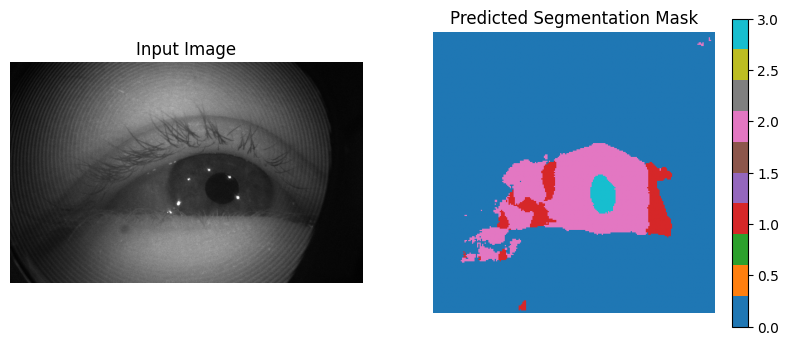

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from vitsModel.PrivacyVitsModel import PrivacyVitsModel  # Assuming this is your model class

image_path = './openEDS/openEDS/S_1/1.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(image, (224, 224))
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)
# img = img.astype(np.float32) / 255.0  # Normalize

model = PrivacyVitsModel.load_model("./vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5")

predicted_mask = model.predict(img)
predicted_mask = np.argmax(predicted_mask, axis=-1)[0]

# custom_objects = {
#             'GaussianBlur': GaussianBlur,
#             'GaussianNoiseLayer': GaussianNoiseLayer,
#             'WeightNoiseLayer': WeightNoiseLayer,
#             'FeatureEncryptionLayer': FeatureEncryptionLayer,
#             'LightInvarianceLayer': LightInvarianceLayer,
#             'dice_coefficient_multiclass': dice_coefficient_multiclass,
#             'iou_metric_multiclass': iou_metric_multiclass,
#         }
# model = tf.keras.models.load_model("privacy_preserving_unet_medium_light_invariance.h5", custom_objects=custom_objects)

print("Predicted mask shape:", predicted_mask.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')

Loading images...
Total images found: 27431
Total labels found: 27431
📊 Loading batch 3: indices 8000 to 11999
Loaded: (4000, 224, 224, 1)

PRIVACY-PRESERVING MODEL


✅ Model loaded from ./vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2.h5

=== Model Architecture Analysis ===
Found last transformer at layer 12: transformer_block_15
Extracting from layer 12: transformer_block_15
Output shape: (custom layer, shape will be determined at runtime)


2025-11-19 23:05:33.286210: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2025-11-19 23:05:33.410931: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 4 bytes spill stores, 4 bytes spill loads

2025-11-19 23:05:33.588852: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 8 bytes spill stores, 8 bytes spill loads

2025-11-19 23:05:33.732074: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 4 bytes spill stores, 4 bytes spill loads

2025-11-19 23:05:33.766533: I external/local_xla/xla/strea

Actual output shape: (1, 197, 768)

Extracting features...
  Progress: 0/4000


2025-11-19 23:05:40.938579: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 8 bytes spill stores, 8 bytes spill loads

2025-11-19 23:05:41.145622: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2', 8 bytes spill stores, 8 bytes spill loads

2025-11-19 23:05:41.553646: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 52 bytes spill stores, 52 bytes spill loads

2025-11-19 23:05:42.180465: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 72 bytes spill stores, 72 bytes spill loads

2025-11-19 23:05:42.485180: I external/local_xla/xla/strea

  Progress: 160/4000
  Progress: 320/4000
  Progress: 480/4000
  Progress: 640/4000
  Progress: 800/4000
  Progress: 960/4000
  Progress: 1120/4000
  Progress: 1280/4000
  Progress: 1440/4000
  Progress: 1600/4000
  Progress: 1760/4000
  Progress: 1920/4000
  Progress: 2080/4000
  Progress: 2240/4000
  Progress: 2400/4000
  Progress: 2560/4000
  Progress: 2720/4000
  Progress: 2880/4000
  Progress: 3040/4000
  Progress: 3200/4000
  Progress: 3360/4000
  Progress: 3520/4000
  Progress: 3680/4000
  Progress: 3840/4000
Raw features shape: (4000, 197, 768)
After extracting CLS token: (4000, 768)
Features for t-SNE: (4000, 768)
Computing t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4000 samples in 0.008s...
[t-SNE] Computed neighbors for 4000 samples in 1.637s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4000
[t-SNE] Computed conditional probabilities for sample 2000 / 4000
[t-SNE] Computed conditional probabilities for sample 3000 / 4000
[t-SNE] Com

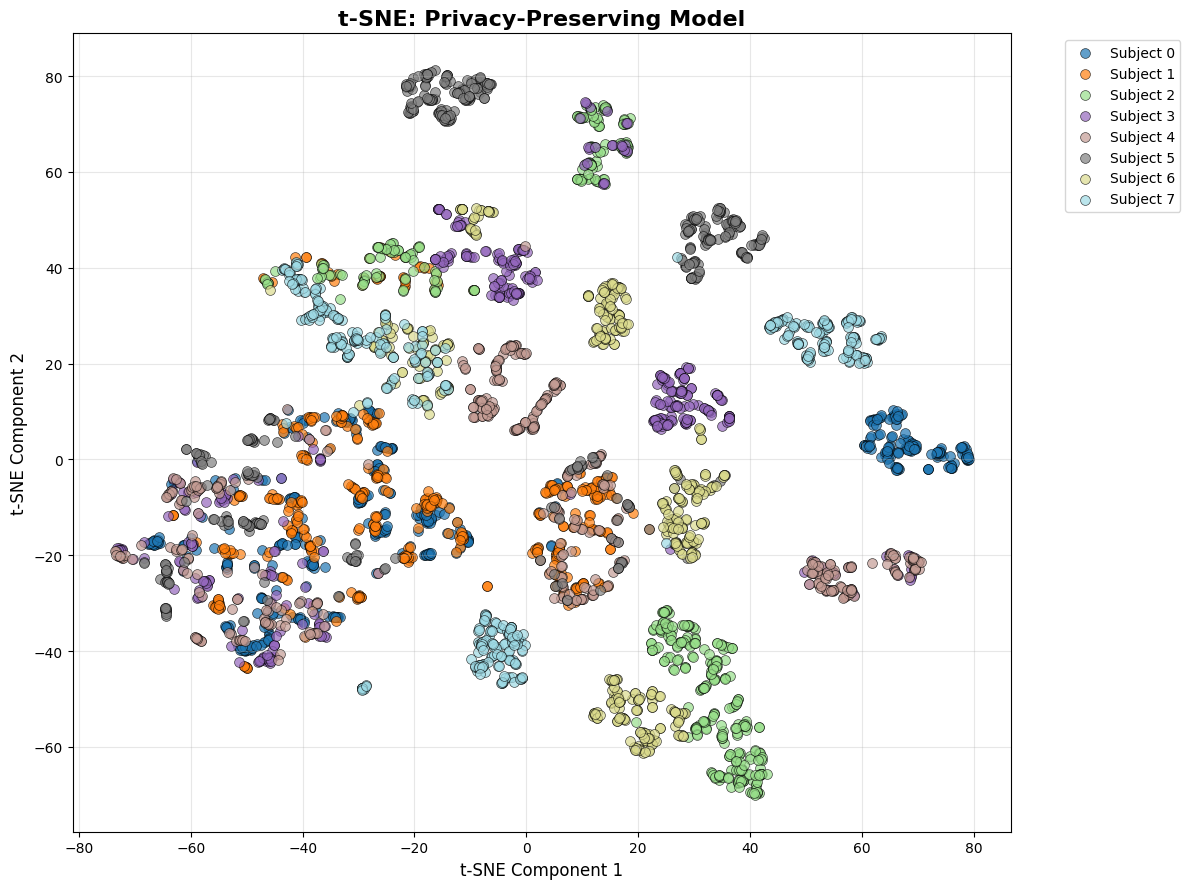


✓ Done!


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from vitsModel.PrivacyVitsModel import PrivacyVitsModel
from vitsModel.DataLoader import DataLoader
# from your_module import DataLoader

def extract_features_vit(model, images):
    """Extract features from Vision Transformer - handles custom layers"""
    print("\n=== Model Architecture Analysis ===")
    
    # Find decoder start
    decoder_start_idx = None
    for i, layer in enumerate(model.layers):
        layer_name_lower = layer.name.lower()
        if any(keyword in layer_name_lower for keyword in 
               ['conv2d_transpose', 'upsampling', 'decoder', 'up_sampling']):
            decoder_start_idx = i
            print(f"Found decoder at layer {i}: {layer.name}")
            break
    
    if decoder_start_idx and decoder_start_idx > 5:
        feature_layer_idx = decoder_start_idx - 1
    else:
        # Look for the last TransformerBlock
        for i in range(len(model.layers) - 1, -1, -1):
            if 'transformer' in model.layers[i].name.lower():
                feature_layer_idx = i
                print(f"Found last transformer at layer {i}: {model.layers[i].name}")
                break
        else:
            feature_layer_idx = -10
    
    print(f"Extracting from layer {feature_layer_idx}: {model.layers[feature_layer_idx].name}")
    
    # Try to get output shape, handle custom layers gracefully
    try:
        print(f"Output shape: {model.layers[feature_layer_idx].output_shape}")
    except AttributeError:
        print(f"Output shape: (custom layer, shape will be determined at runtime)")
    
    feature_extractor = tf.keras.Model(
        inputs=model.input,
        outputs=model.layers[feature_layer_idx].output
    )
    
    # Test with a single sample to determine output shape
    test_output = feature_extractor.predict(images[:1], verbose=0)
    print(f"Actual output shape: {test_output.shape}\n")
    
    # Extract features in batches
    batch_size = 16
    features_list = []
    
    print("Extracting features...")
    for i in range(0, len(images), batch_size):
        if i % (batch_size * 10) == 0:
            print(f"  Progress: {i}/{len(images)}")
        batch = images[i:i+batch_size]
        batch_features = feature_extractor.predict(batch, verbose=0)
        features_list.append(batch_features)
    
    features = np.concatenate(features_list, axis=0)
    print(f"Raw features shape: {features.shape}")
    
    # Process to get fixed-size vectors
    if len(features.shape) == 4:  # (batch, H, W, C)
        features = np.mean(features, axis=(1, 2))
        print(f"After Global Average Pooling: {features.shape}")
    elif len(features.shape) == 3:  # (batch, tokens, dim)
        features = features[:, 0, :]  # CLS token
        print(f"After extracting CLS token: {features.shape}")
    
    return features

def visualize_tsne(features, labels, title="t-SNE Visualization", save_path=None):
    """Create t-SNE visualization"""
    # Flatten if needed
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)
    
    print(f"Features for t-SNE: {features.shape}")
    
    # Standardize
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    # t-SNE - use max_iter instead of n_iter
    print("Computing t-SNE...")
    perplexity = min(30, len(features) - 1)
    tsne = TSNE(
        n_components=2, 
        random_state=42, 
        perplexity=perplexity, 
        max_iter=1000,  # Changed from n_iter to max_iter
        verbose=1
    )
    features_2d = tsne.fit_transform(features_scaled)
    
    # Plot
    plt.figure(figsize=(12, 9))
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                   c=[colors[i]], label=f'Subject {label}', 
                   alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ==================== MAIN ====================

# Load data
image_dir_path = './openEDS/openEDS/train/images'
label_dir_path = './openEDS/openEDS/train/labels'

print("Loading images...")
images, labels = DataLoader.load_grayscale_images_label_pairs(
    image_dir_path, label_dir_path,
    step=2, step_size=4000,
    target_size=(224, 224),
    add_noise=False,
    normalize_on_load=False
)

print(f"Loaded: {images.shape}")

# Create subject IDs (ADJUST THIS BASED ON YOUR DATA!)
# You need to extract actual subject IDs from filenames or directory structure
num_subjects = 8
samples_per_subject = len(images) // num_subjects
subject_ids = np.repeat(range(num_subjects), samples_per_subject)[:len(images)]

# Prepare images
if len(images.shape) == 3:
    images = np.expand_dims(images, axis=-1)

# Load model and extract features
print("\n" + "="*60)
print("PRIVACY-PRESERVING MODEL")
print("="*60)
model_name = "vit_eye_model_dp0.15_as0.3_ss0.1_bdr0.2"
model = PrivacyVitsModel.load_model(f"./{model_name}.h5")
features = extract_features_vit(model, images)

# Visualize
visualize_tsne(features, subject_ids, 
               title="t-SNE: Privacy-Preserving Model",
               save_path=f"tsne_privacy_model_{model_name}.png")

print("\n✓ Done!")